In [ ]:
import duckdb
import polars as pl
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

con = duckdb.connect("../data/m5.db")
con.execute("SHOW TABLES").fetchdf()
df = con.execute("SELECT * FROM dataset_raw LIMIT 5").fetchdf()

df

In [ ]:
con.execute("""
SELECT
    event_name,
    event_type,
    COUNT(*) AS n
FROM dataset_raw
WHERE event_name IS NOT NULL
GROUP BY 1, 2
ORDER BY 1
""").fetchdf()

In [ ]:
df_eventos = con.execute("""
WITH daily AS (
    SELECT
        CAST(date AS DATE) AS date,
        event_name,
        SUM(sales) AS sales
    FROM dataset_raw
    GROUP BY 1, 2
),

baseline AS (
    SELECT
        AVG(sales) AS avg_sales_normal
    FROM daily
    WHERE event_name IS NULL
),

event_summary AS (
    SELECT
        event_name,
        COUNT(*) AS n_days,
        AVG(sales) AS avg_sales_event,
        MIN(sales) AS min_sales,
        MAX(sales) AS max_sales
    FROM daily
    WHERE event_name IS NOT NULL
    GROUP BY event_name
)

SELECT
    e.event_name,
    e.n_days,
    ROUND(e.avg_sales_event, 2) AS avg_sales_event,
    ROUND(b.avg_sales_normal, 2) AS avg_sales_normal,

    ROUND(
        100.0 * (e.avg_sales_event / b.avg_sales_normal - 1),
        2
    ) AS pct_change_vs_normal

FROM event_summary e
CROSS JOIN baseline b
ORDER BY pct_change_vs_normal
""").fetchdf()

In [ ]:
df_eventos

In [ ]:
df_eventos_principales = con.execute("""
WITH daily AS (
    SELECT
        CAST(date AS DATE) AS date,
        SUM(sales) AS sales,
        MAX(event_name) AS event_name
    FROM dataset_raw
    GROUP BY 1
),

event_analysis AS (
    SELECT
        e.event_name,
        e.date AS event_date,

        AVG(
            CASE
                WHEN d.date BETWEEN e.date - INTERVAL 3 DAY
                                AND e.date - INTERVAL 1 DAY
                THEN d.sales
            END
        ) AS avg_sales_pre,

        e.sales AS sales_event,

        AVG(
            CASE
                WHEN d.date BETWEEN e.date + INTERVAL 1 DAY
                                AND e.date + INTERVAL 3 DAY
                THEN d.sales
            END
        ) AS avg_sales_post

    FROM daily e
    JOIN daily d
        ON d.date BETWEEN e.date - INTERVAL 3 DAY
                       AND e.date + INTERVAL 3 DAY

    WHERE e.event_name IN (
        'Thanksgiving',
        'NewYear',
        'Christmas',
        'Halloween',
        'Easter',
        'SuperBowl',
        'LaborDay',
        'Mother''s day',
        'Father''s day',
        'ValentinesDay'
    )

    GROUP BY
        e.event_name,
        e.date,
        e.sales
)

SELECT
    event_name,
    event_date,

    ROUND(avg_sales_pre, 2) AS avg_sales_pre,
    ROUND(sales_event, 2) AS sales_event,
    ROUND(avg_sales_post, 2) AS avg_sales_post,

    ROUND(
        100 * (sales_event / NULLIF(avg_sales_pre, 0) - 1),
        2
    ) AS pct_event_vs_pre,

    ROUND(
        100 * (avg_sales_post / NULLIF(sales_event, 0) - 1),
        2
    ) AS pct_post_vs_event

FROM event_analysis

ORDER BY event_name, event_date
""").fetchdf()

In [25]:
summary = (
    df_eventos_principales.groupby("event_name")
      .agg(
          avg_sales_pre=("avg_sales_pre", "mean"),
          avg_sales_event=("sales_event", "mean"),
          avg_sales_post=("avg_sales_post", "mean"),
      )
      .reset_index()
)


summary["var_pre_post"] = (
    (summary["avg_sales_post"] / summary["avg_sales_pre"] - 1)
)

summary.sort_values("var_pre_post", ascending=False, inplace=True)

summary

,event_name,avg_sales_pre,avg_sales_event,avg_sales_post,var_pre_post
3,Halloween,31244.734000,30059.400000,38394.602000,0.228834
6,NewYear,33532.934000,25768.400000,36804.400000,0.097560
8,Thanksgiving,32185.266000,21130.000000,30306.068000,-0.058387
5,Mother's day,36422.110000,36111.000000,33447.945000,-0.081658
9,ValentinesDay,38099.166667,33495.666667,34954.556667,-0.082538
0,Christmas,34366.532000,15.600000,31469.068000,-0.084311
7,SuperBowl,37486.056667,40924.000000,31825.055000,-0.151016
2,Father's day,36086.165000,36562.000000,30075.920000,-0.166553
4,LaborDay,40079.002000,42154.600000,32708.668000,-0.183895
1,Easter,40561.334000,39517.600000,32959.934000,-0.187405


In [ ]:
df_eventos_principales

In [ ]:


plot_df["Variación post vs pre (%)"] = (
    (plot_df["post"] / plot_df["pre"] - 1) * 100
)

plot_df = plot_df.sort_values("Variación evento vs pre (%)")

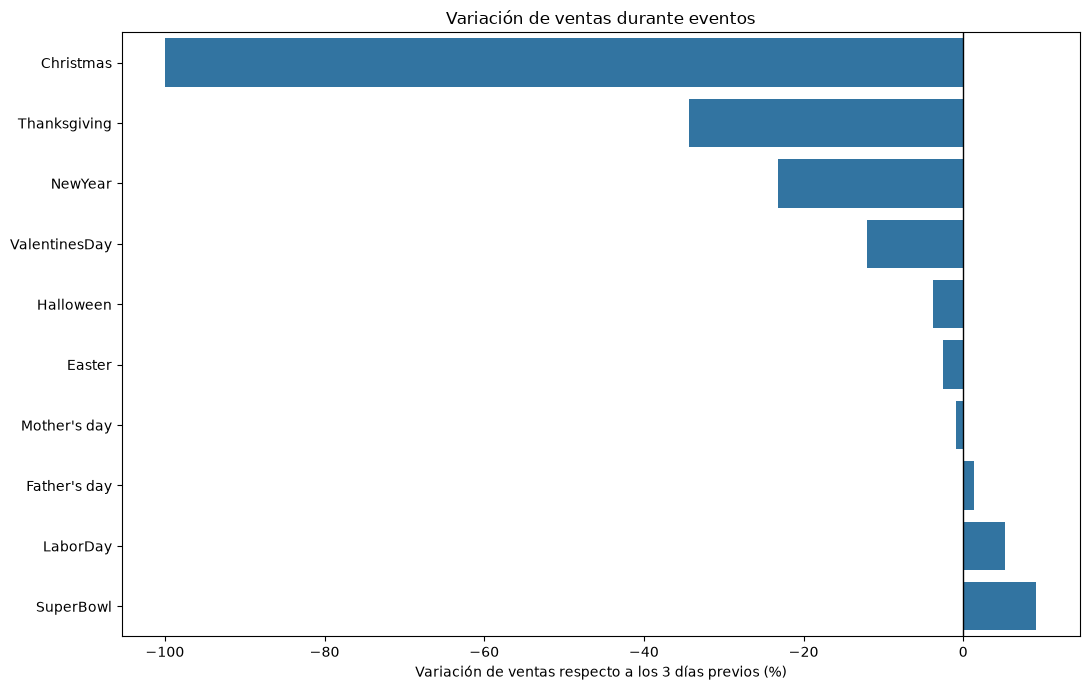

In [21]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=plot_df,
    x="Variación evento vs pre (%)",
    y="event_name"
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Variación de ventas respecto a los 3 días previos (%)")
plt.ylabel("")
plt.title("Variación de ventas durante eventos")

plt.tight_layout()
plt.show()